In [138]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [139]:
import os

dataset_path = "/content/drive/MyDrive/GCP_Assignment_Datasets"

print(os.listdir(dataset_path))

['train_dataset', 'test_dataset']


In [140]:
train_path = os.path.join(dataset_path, "/content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset")

print(os.listdir(train_path)[:10])

['gcp_marks.json', 'Egypt-New city', '231129_CTD', 'Seashell Ras el Hekma', 'Deora Limestone Mine', 'Vedanta GOA Bicholim', 'UTCL UNCL Additional Area', 'RDCW-Reddipalayam Limestone Mine', 'scout_966', 'Adani GP-III CG']


In [141]:
import json

json_path = os.path.join(train_path, "/content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset/gcp_marks.json")

with open(json_path, "r") as f:
    labels = json.load(f)

print("Total labeled images:", len(labels))

Total labeled images: 1000


In [142]:
first_key = list(labels.keys())[0]

print("Image path:", first_key)
print("Label:", labels[first_key])

Image path: scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG
Label: {'mark': {'x': 3272.769145523532, 'y': 1089.3292198344861}, 'verified_shape': 'Cross'}


In [143]:
import cv2
import matplotlib.pyplot as plt
import os

# build correct path
image_full_path = os.path.join(train_path, first_key)

print("Full path:", image_full_path)

# check if file exists
print("Exists:", os.path.exists(image_full_path))

# load image
img = cv2.imread(image_full_path)

print("Image loaded:", img is not None)


Full path: /content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset/scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG
Exists: True
Image loaded: True


(np.float64(-0.5), np.float64(4095.5), np.float64(3067.5), np.float64(-0.5))

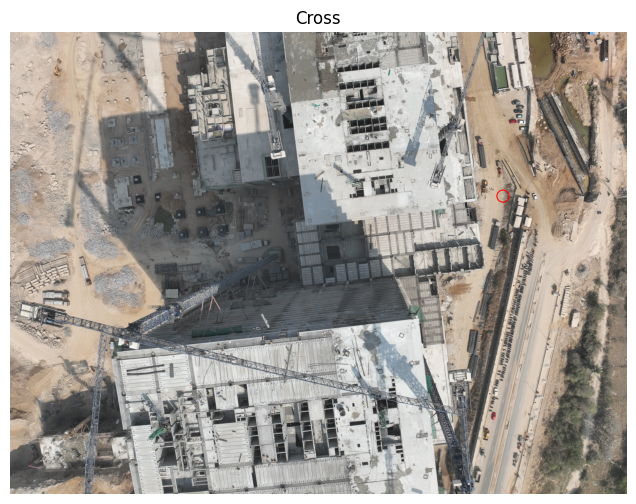

In [144]:
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

x = int(labels[first_key]["mark"]["x"])
y = int(labels[first_key]["mark"]["y"])

cv2.circle(img, (x, y), 40, (255,0,0), 6)

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.title(labels[first_key]["verified_shape"])
plt.axis("off")

In [145]:
samples = []

missing_shape = 0

for rel_path, info in labels.items():

    # skip if shape label missing
    if "verified_shape" not in info:
        missing_shape += 1
        continue

    image_path = os.path.join(train_path, rel_path)

    x = info["mark"]["x"]
    y = info["mark"]["y"]
    shape = info["verified_shape"]

    samples.append({
        "image_path": image_path,
        "x": x,
        "y": y,
        "shape": shape
    })

print("Total usable samples:", len(samples))
print("Missing shape labels:", missing_shape)

print(samples[0])

Total usable samples: 996
Missing shape labels: 4
{'image_path': '/content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset/scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG', 'x': 3272.769145523532, 'y': 1089.3292198344861, 'shape': 'Cross'}


In [146]:
# normalize shape names first
for s in samples:
    if s["shape"] == "L-Shape":
        s["shape"] = "L-Shaped"

# encoding dictionary
shape_to_label = {
    "Cross": 0,
    "Square": 1,
    "L-Shaped": 2
}

label_to_shape = {v:k for k,v in shape_to_label.items()}

# assign numeric labels
for s in samples:
    s["shape_id"] = shape_to_label[s["shape"]]

print(samples[0])

{'image_path': '/content/drive/MyDrive/GCP_Assignment_Datasets/train_dataset/scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG', 'x': 3272.769145523532, 'y': 1089.3292198344861, 'shape': 'Cross', 'shape_id': 0}


Original size: 4096 3068
Scaled coordinates: 409.0961431904415 181.79157775595075


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

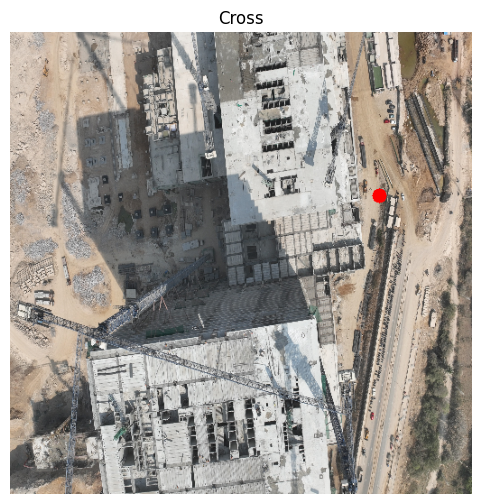

In [147]:
import cv2
import matplotlib.pyplot as plt

# select first sample
sample = samples[0]

# load image
img = cv2.imread(sample["image_path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w = img.shape[:2]

print("Original size:", w, h)

# resize
new_size = 512
img_resized = cv2.resize(img, (new_size, new_size))

# scale coordinates
x = sample["x"]
y = sample["y"]

x_scaled = x * (new_size / w)
y_scaled = y * (new_size / h)

print("Scaled coordinates:", x_scaled, y_scaled)

# draw marker
cv2.circle(img_resized, (int(x_scaled), int(y_scaled)), 8, (255,0,0), -1)

plt.figure(figsize=(6,6))
plt.imshow(img_resized)
plt.title(sample["shape"])
plt.axis("off")

In [148]:
import torch
import torchvision

print("Torch version:", torch.__version__)

Torch version: 2.10.0+cu128


In [149]:
import torch
from torch.utils.data import Dataset
import cv2

class GCPDataset(Dataset):

    def __init__(self, samples, img_size=512):
        self.samples = samples
        self.img_size = img_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        sample = self.samples[idx]

        img = cv2.imread(sample["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w = img.shape[:2]

        # resize image
        img = cv2.resize(img, (self.img_size, self.img_size))

        # scale coordinates
        x = (sample["x"] * (self.img_size / w)) / self.img_size
        y = (sample["y"] * (self.img_size / h)) / self.img_size

        # normalize image
        img = img / 255.0

        # convert to tensor
        img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)

        keypoint = torch.tensor([x, y], dtype=torch.float32)

        shape = torch.tensor(sample["shape_id"], dtype=torch.long)

        return img, keypoint, shape

In [150]:
dataset = GCPDataset(samples, img_size=224)

print("Dataset size:", len(dataset))

img, kp, shape = dataset[0]

print("Image shape:", img.shape)
print("Keypoint:", kp)
print("Shape class:", shape)

Dataset size: 996
Image shape: torch.Size([3, 224, 224])
Keypoint: tensor([0.7990, 0.3551])
Shape class: tensor(0)


In [151]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

print("DataLoader created")

DataLoader created


In [152]:
batch = next(iter(train_loader))

images, keypoints, shapes = batch

print("Images batch shape:", images.shape)
print("Keypoints batch shape:", keypoints.shape)
print("Shapes batch shape:", shapes.shape)

Images batch shape: torch.Size([16, 3, 224, 224])
Keypoints batch shape: torch.Size([16, 2])
Shapes batch shape: torch.Size([16])


In [153]:
import torch

print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version: 2.10.0+cu128
GPU available: True
GPU name: Tesla T4


In [154]:
import torch
import torch.nn as nn
import torchvision.models as models

class GCPModel(nn.Module):

    def __init__(self):
        super(GCPModel, self).__init__()

        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        self.features = nn.Sequential(*list(backbone.children())[:-1])

        self.dropout = nn.Dropout(p=0.3)

        self.keypoint_head = nn.Linear(512, 2)
        self.shape_head = nn.Linear(512, 3)

    def forward(self, x):

        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)

        keypoints = self.keypoint_head(x)
        shapes = self.shape_head(x)

        return keypoints, shapes


model = GCPModel()

In [155]:
for param in model.features.parameters():
    param.requires_grad = False

In [156]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

Using device: cuda


In [157]:
keypoint_loss_fn = nn.MSELoss()
shape_loss_fn = nn.CrossEntropyLoss()

In [158]:
import torch.optim as optim

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.001
)

print("Optimizer created")

Optimizer created


In [159]:
epochs = 20

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, keypoints, shapes in train_loader:

        images = images.to(device)
        keypoints = keypoints.to(device)
        shapes = shapes.to(device)

        kp_pred, shape_pred = model(images)

        kp_loss = keypoint_loss_fn(kp_pred, keypoints)
        shape_loss = shape_loss_fn(shape_pred, shapes)

        loss = kp_loss * 10 + shape_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{epochs} Loss: {avg_loss}")

Epoch 1/20 Loss: 4.928885236619011
Epoch 2/20 Loss: 2.7998643148513067
Epoch 3/20 Loss: 2.1306838989257812
Epoch 4/20 Loss: 1.677960747764224
Epoch 5/20 Loss: 1.464744011561076
Epoch 6/20 Loss: 1.2823278071388367
Epoch 7/20 Loss: 1.206584013643719
Epoch 8/20 Loss: 1.077870089856405
Epoch 9/20 Loss: 1.0215363322742401
Epoch 10/20 Loss: 1.0326547944356526
Epoch 11/20 Loss: 1.0238670091780404
Epoch 12/20 Loss: 0.9570337533950806
Epoch 13/20 Loss: 1.0278073170828441
Epoch 14/20 Loss: 0.9781197366260347
Epoch 15/20 Loss: 0.9596656418982006
Epoch 16/20 Loss: 1.0252162388392858
Epoch 17/20 Loss: 0.9671532199496314
Epoch 18/20 Loss: 1.0407902579458932
Epoch 19/20 Loss: 0.9646256953950912
Epoch 20/20 Loss: 0.9948432029239715


In [160]:
torch.save(model.state_dict(), "gcp_model.pth")
print("Model saved")

Model saved


In [161]:
class GCPTestDataset(Dataset):

    def __init__(self, root_dir, img_size=224):
        self.root_dir = root_dir
        self.img_size = img_size
        self.image_paths = []

        for root, dirs, files in os.walk(root_dir):
            for f in files:
                if f.lower().endswith(".jpg") or f.lower().endswith(".jpeg"):
                    self.image_paths.append(os.path.join(root, f))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w = img.shape[:2]

        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img / 255.0

        img = torch.tensor(img, dtype=torch.float32).permute(2,0,1)

        return img, img_path, h, w

In [162]:
test_path = os.path.join(dataset_path, "test_dataset")

test_dataset = GCPTestDataset(test_path)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print("Total test images:", len(test_dataset))

Total test images: 300


In [163]:
model.eval()

predictions = {}

with torch.no_grad():

    for img, path, h, w in test_loader:

        img = img.to(device)

        kp_pred, shape_pred = model(img)

        # predicted normalized coords
        x = kp_pred[0][0].item()
        y = kp_pred[0][1].item()

        # convert back to pixel space
        x = x * w.item()
        y = y * h.item()

        shape_id = torch.argmax(shape_pred, dim=1).item()

        shape_name = label_to_shape[shape_id]

        rel_path = os.path.relpath(path[0], test_path)

        predictions[rel_path] = {
            "mark": {
                "x": float(x),
                "y": float(y)
            },
            "verified_shape": shape_name
        }

In [164]:
print(len(predictions))
list(predictions.items())[0]

300


('Amli Limestone Mine/MCDR_2024/GCP-78/DJI_20240414123637_0249_V.JPG',
 {'mark': {'x': 3170.844482421875, 'y': 1254.389605641365},
  'verified_shape': 'Square'})

In [165]:
import json

with open("predictions.json", "w") as f:
    json.dump(predictions, f, indent=4)

print("predictions.json created")

predictions.json created
